In [24]:
import pandas as pd
import numpy as np
import os
import ansys.aedt.core
import math
import shutil
import time
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

In [25]:
## 변수 정의 ##

# 형상

depth = 40     # 모델의 적층깊이
num_pole = 10    # 자석의 갯수
m_w = 20   # 자석의 너비
m_h = 5   # 자석의 높이
gap_w = m_w * 0.3   # 자석사이의 공간
my_th = 15   # 자석판의 두께
num_slot = 3   # 슬롯 개수
airgap = 1   # 공극 길이
t_w = 6   # teeth 폭
t_g = (52 / 3 - 6) / 2   # teeth 간격
J_rated = 3   # 코일 영역 전류밀도
cy_th = 15   # 요크 두께
c_w = 5   # 코일의 너비
c_h = 15   # 코일의 높이
t_h = c_h   # 치의 높이
my_w = (m_w * num_pole + gap_w * (num_pole - 1)) / 3 * 4   # 자석판의 너비


# 전류 설정

turn_c = 100    # 코일의 턴수

area = c_w * c_h   # terminal 면적

current_rated = J_rated * area / turn_c    # 상 정격 전류

gamma = math.pi * 0   # 전류각 미스매치
theta_elec_offset = math.pi / 2 + gamma   # i_d=0 제어 및 미스매치

freq_elec = 10      # 전기각 주파수

current_a = f"{current_rated}*cos(2*pi*{freq_elec}*Time + {theta_elec_offset})"

current_b = 0

current_c = 0


# mover 이동

movement = True   # True: +x방향 이동, False: -x방향 이동

veolcity_stator = 2*(m_w+gap_w)/1000/(1/freq_elec)   # 1주기 속도 (m/s)
# veolcity_stator = 0   # mover 이동 속도


In [ ]:
## Desktop 만들고, Project와 Design 만들기 ##

# creating Desktop object
# write the aedt(ansys electronics desktop) version and whether you are using a student license
from ansys.aedt.core import Desktop
DT = Desktop(version="2024.2", non_graphical=True, student_version=False)

# Option to automatically save at regular intervals
# release it because The simulation is running on a script basis 
DT.disable_autosave()

# solution type
sol_type = "Transient"

# creating maxwell3D design object
# write solution type and whether you are using a student license
# 처음 design 객체를 생성하면 새로운 project와 함께 생성되고, project와 design은 임의의 이름을 가짐
from ansys.aedt.core.maxwell import Maxwell2d
M2D = Maxwell2d(solution_type=sol_type, student_version=False)
M2D.autosave_disable()
# ansys 레코딩 코드를 사용하기 위한 odesign 객체
oDesign = M2D.odesign


PyAEDT INFO: Python version 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 18:56:27) [GCC 11.2.0].
PyAEDT INFO: PyAEDT version 0.15.0.
PyAEDT INFO: Initializing new Desktop session.
PyAEDT INFO: Log on console is enabled.
PyAEDT INFO: Log on file /tmp/pyaedt_harry261_f1364a5e-64e5-41f1-97f9-85e162536a8f.log is enabled.
PyAEDT INFO: Log on AEDT is disabled.
PyAEDT INFO: Debug logger is disabled. PyAEDT methods will not be logged.
PyAEDT INFO: Launching PyAEDT with gRPC plugin.
PyAEDT INFO: New AEDT session is starting on gRPC port 46263.
PyAEDT INFO: Electronics Desktop license available.
PyAEDT WARNING: Failed to start on gRPC port: 46263. Trying to start on 40151.
PyAEDT INFO: Electronics Desktop license available.
PyAEDT ERROR: Failed to start on gRPC port: 40151.
PyAEDT INFO: AEDT installation Path /opt/ohpc/pub/Electronics/v242/Linux64/


In [1]:
DT.close_desktop()

NameError: name 'DT' is not defined

In [19]:
## Project 폴더 만들기 ##

# project name
# change the name to what you want
proj_name = "linear_motor_3slot_2D"

# path of project directory
from os.path import join
dir = join(os.getcwd(), proj_name)
# dir = os.getcwd() + f"\\{proj_name}"
print(dir)

# # project 폴더 생성
# # 실행 전 이전 폴더 삭제 필요
# os.mkdir(dir)

# the name of maxwell3D design object
desi_name = "linear_motor_3slot_2D"


/gpfs/home1/harry261/Documents/Projects/hw4/hw4ex/a_current_moving/linear_motor_3slot_2D


In [20]:
## Project 저장하고, Design 이름 설정 ##
M2D.autosave_disable()
# design 객체가 존재하는 project 객체
proj = M2D.oproject

# # project 저장
projPath = join(dir, f"{proj_name}.aedt")
proj.SaveAs(projPath, True)
# proj.SaveAs(f"{dir}\\{proj_name}.aedt", True)

# design을 원하는 이름으로 변경
M2D.rename_design(desi_name, save=False)

True

In [21]:
## design 변수 정의 ##


M2D["depth"] = f"{depth}mm"
M2D["num_pole"] = f"{num_pole}"
M2D["m_w"] = f"{m_w}mm"
M2D["m_h"] = f"{m_h}mm"
M2D["gap_w"] = f"{gap_w}mm"
M2D["my_th"] = f"{my_th}mm"
M2D["num_slot"] = f"{num_slot}"
M2D["airgap"] = f"{airgap}mm"
M2D["t_w"] = f"{t_w}mm"
M2D["t_g"] = f"{t_g}mm"
M2D["J_rated"] = f"{J_rated}"
M2D["cy_th"] = f"{cy_th}mm"
M2D["c_w"] = f"{c_w}mm"
M2D["c_h"] = f"{c_h}mm"
M2D["t_h"] = f"{t_h}mm"
M2D["my_w"] = f"{my_w}mm"
M2D["turn_c"] = f"{turn_c}"
M2D["current_rated"] = f"{current_rated}"
M2D["gamma"] = f"{gamma}"
M2D["theta_elec_offset"] = f"{theta_elec_offset}"
M2D["freq_elec"] = f"{freq_elec}"


In [22]:
## Analyze Setup 설정 ##

# model depth 설정
M2D.model_depth = "depth"

oModule = oDesign.GetModule("AnalysisSetup")
oModule.InsertSetup("Transient", 
	[
		"NAME:Setup1",
		"Enabled:="		, True,
		[
			"NAME:MeshLink",
			"ImportMesh:="		, False
		],
		"NonlinearSolverResidual:=", "0.0001",
		"TimeIntegrationMethod:=", "BackwardEuler",
		"SmoothBHCurve:="	, False,
		"StopTime:="		, "0.1s",
		"TimeStep:="		, "0.001s",
		"OutputError:="		, False,
		"OutputPerObjectCoreLoss:=", False,
		"OutputPerObjectSolidLoss:=", False,
		"UseControlProgram:="	, False,
		"ControlProgramName:="	, "",
		"ControlProgramArg:="	, " ",
		"CallCtrlProgAfterLastStep:=", False,
		"FastReachSteadyState:=", False,
		"AutoDetectSteadyState:=", False,
		"IsGeneralTransient:="	, True,
		"IsHalfPeriodicTransient:=", False,
		"SaveFieldsType:="	, "Every N Steps",
		"N Steps:="		, "1",
		"Steps From:="		, "0s",
		"Steps To:="		, "0.1s",
		"UseNonLinearIterNum:="	, False,
		"CacheSaveKind:="	, "Count",
		"NumberSolveSteps:="	, 1,
		"RangeStart:="		, "0s",
		"RangeEnd:="		, "0.1s",
		"UseAdaptiveTimeStep:="	, False,
		"InitialTimeStep:="	, "0.002s",
		"MinTimeStep:="		, "0.001s",
		"MaxTimeStep:="		, "0.003s",
		"TimeStepErrTolerance:=", 0.0001,
		"RelaxationFactor:="	, 1
	])


my_setup = M2D.setups[0]

PyAEDT ERROR: **************************************************************
PyAEDT ERROR:   File "<frozen runpy>", line 198, in _run_module_as_main
PyAEDT ERROR:   File "<frozen runpy>", line 88, in _run_code
PyAEDT ERROR:   File "/home1/harry261/miniconda3/envs/pyaedt_env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
PyAEDT ERROR:     app.launch_new_instance()
PyAEDT ERROR:   File "/home1/harry261/miniconda3/envs/pyaedt_env/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
PyAEDT ERROR:     app.start()
PyAEDT ERROR:   File "/home1/harry261/miniconda3/envs/pyaedt_env/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
PyAEDT ERROR:     self.io_loop.start()
PyAEDT ERROR:   File "/home1/harry261/miniconda3/envs/pyaedt_env/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start
PyAEDT ERROR:     self.asyncio_loop.run_forever()
PyAEDT ERROR:   File "/home1/harry261/miniconda3/

In [8]:
## Material 정의 ##

# 철
steel = M2D.materials.duplicate_material("steel_1008", name="steel")
steel.stacking_type = "Lamination"      # eddy current loss 를 줄이기 위한 lamination 고려
steel.stacking_factor = 0.95
steel.stacking_direction = "V(3)"

# 자석 n극이 +z
magnet_n = M2D.materials.duplicate_material("NdFe35", name="magnet_n")
magnet_n.get_magnetic_coercivity()  # 자화 확인
magnet_n.set_magnetic_coercivity(value=-890000, x=0, y=1, z=0)  # 자화 방향 수정(+z)

# 자석 s극이 -z
magnet_s = M2D.materials.duplicate_material("NdFe35", name="magnet_s")
magnet_s.get_magnetic_coercivity()  # 자화 확인
magnet_s.set_magnetic_coercivity(value=-890000, x=0, y=-1, z=0)  # 자화 방향 수정(-z)

# 코일 구리
copper_c = M2D.materials.duplicate_material("copper", name="copper_c")


PyAEDT INFO: Materials class has been initialized! Elapsed time: 0m 0sec


In [9]:
## 형상그리기 및 바운더리 설정 ##

# 자석 판 그리기

origin = ["-my_w/2", "-my_th/2"]
sizes = ["my_w", "my_th"]
substrate = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name='substrate', material=steel, non_model=False)

# 자석 그리기

origin = [0, "-m_h/2"]
sizes = ["m_w", "m_h"]
magnet_1 = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name="magnet_1", material=magnet_s, non_model=False)

vector = ["2*(m_w+gap_w)", 0]
M2D.modeler.duplicate_along_line(assignment=magnet_1, vector=vector, clones=num_pole/2, attach=True, is_3d_comp=False, duplicate_assignment=True)   # 복제

magnet_1.color = (0, 0, 255)


origin = ["gap_w+m_w", "-m_h/2"]
sizes = ["m_w", "m_h"]
magnet_2 = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name="magnet_2", material=magnet_n, non_model=False)

vector = ["2*(m_w+gap_w)", 0]
M2D.modeler.duplicate_along_line(assignment=magnet_2, vector=vector, clones=num_pole/2, attach=True, is_3d_comp=False, duplicate_assignment=True)   # 복제

magnet_2.color = (255, 0, 0)


vector = ["-( m_w*num_pole+gap_w*(num_pole-1) )/2", "my_th/2+m_h/2"]
M2D.modeler.move(assignment=[magnet_1, magnet_2], vector=vector)    # 이동


M2D.modeler.separate_bodies(assignment=magnet_1, create_group=False)
magnet_1_1 = M2D.modeler.object_list[-4]
magnet_1_2 = M2D.modeler.object_list[-3]
magnet_1_3 = M2D.modeler.object_list[-2]
magnet_1_4 = M2D.modeler.object_list[-1]
M2D.modeler.separate_bodies(assignment=magnet_2, create_group=False)
magnet_2_1 = M2D.modeler.object_list[-4]
magnet_2_2 = M2D.modeler.object_list[-3]
magnet_2_3 = M2D.modeler.object_list[-2]
magnet_2_4 = M2D.modeler.object_list[-1]


# slot 그리기

origin = [0, "-t_h/2"]
sizes = ["t_w", "t_h"]
slot_a = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name="slot_a", material="air", non_model=False)


vector=["t_w+2*t_g", 0]
M2D.modeler.duplicate_along_line(assignment=slot_a, vector=vector, clones=2, attach=False, is_3d_comp=False, duplicate_assignment=True)
slot_b = M2D.modeler.object_list[-1]
slot_b.name = "slot_b"

M2D.modeler.duplicate_along_line(assignment=slot_b, vector=vector, clones=2, attach=False, is_3d_comp=False, duplicate_assignment=True)
slot_c = M2D.modeler.object_list[-1]
slot_c.name = "slot_c"


# coil 그리기

origin = ["-c_w", "-t_h/2"]
sizes = ["t_w+2*c_w", "c_h"]
coil_a = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name="coil_a", material=copper_c, non_model=False)


M2D.modeler.subtract(blank_list=coil_a, tool_list=slot_a, keep_originals=True)  # (coil)-(slot)


vector=["t_w+2*t_g", 0]
M2D.modeler.duplicate_along_line(assignment=coil_a, vector=vector, clones=2, attach=False, is_3d_comp=False, duplicate_assignment=True)
coil_b = M2D.modeler.object_list[-1]
coil_b.name = "coil_b"

M2D.modeler.subtract(blank_list=coil_b, tool_list=slot_b, keep_originals=True)  # (coil)-(slot)


vector=["t_w+2*t_g", 0]
M2D.modeler.duplicate_along_line(assignment=coil_b, vector=vector, clones=2, attach=False, is_3d_comp=False, duplicate_assignment=True)
coil_c = M2D.modeler.object_list[-1]
coil_c.name = "coil_c"

M2D.modeler.subtract(blank_list=coil_c, tool_list=slot_c, keep_originals=True)  # (coil)-(slot)


vector = ["-( 1.5*t_w+2*t_g )", 0]
M2D.modeler.move(assignment=[coil_a, coil_b, coil_c, slot_a, slot_b, slot_c], vector=vector)    # 이동


# yoke 그리기

origin = ["-( (t_w+2*t_g)*3*1.3 )/2", "c_h/2"]
sizes = ["( (t_w+2*t_g)*3*1.3 )", "cy_th"]
stator = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name="stator", material="air", non_model=False)


M2D.modeler.unite(assignment=[stator, slot_a, slot_b, slot_c], purge=False, keep_originals=False)

vector = [0, "my_th/2+m_h+airgap+c_h/2"]
M2D.modeler.move(assignment=[stator, coil_a, coil_b, coil_c], vector=vector)    # 이동


# 자석판 이동

# vector = ["3*(gap_w+m_w)/2-t_w-2*t_g", 0]
# M2D.modeler.move(assignment=[substrate, magnet_1, magnet_1_1, magnet_1_2, magnet_1_3, magnet_1_4, magnet_2, magnet_2_1, magnet_2_2, magnet_2_3, magnet_2_4], vector=vector)    # a상-alpha축 정렬
vector = ["-(3*(gap_w+m_w)/2-t_w-2*t_g)", 0]
M2D.modeler.move(assignment=[coil_a, coil_b, coil_c, stator], vector=vector)


# region 그리기

oEditor = oDesign.SetActiveEditor("3D Modeler")
oEditor.CreateRegion(
	[
		"NAME:RegionParameters",
		"+XPaddingType:="	, "Absolute Position",
		"+XPadding:="		, "my_w",
		"-XPaddingType:="	, "Absolute Position",
		"-XPadding:="		, "-my_w",
		"+YPaddingType:="	, "Absolute Position",
		"+YPadding:="		, "my_w",
		"-YPaddingType:="	, "Absolute Position",
		"-YPadding:="		, "-my_w",
		"+ZPaddingType:="	, "Percentage Offset",
		"+ZPadding:="		, "0",
		"-ZPaddingType:="	, "Percentage Offset",
		"-ZPadding:="		, "0",
		[
			"NAME:BoxForVirtualObjects",
			[
				"NAME:LowPoint", 
				1, 
				1, 
				1
			],
			[
				"NAME:HighPoint", 
				-1, 
				-1, 
				-1
			]
		]
	], 
	[
		"NAME:Attributes",
		"Name:="		, "Region",
		"Flags:="		, "Wireframe#",
		"Color:="		, "(143 175 143)",
		"Transparency:="	, 0,
		"PartCoordinateSystem:=", "Global",
		"UDMId:="		, "",
		"MaterialValue:="	, "\"vacuum\"",
		"SurfaceMaterialValue:=", "\"\"",
		"SolveInside:="		, True,
		"ShellElement:="	, False,
		"ShellElementThickness:=", "nan ",
		"ReferenceTemperature:=", "nan ",
		"IsMaterialEditable:="	, True,
		"IsSurfaceMaterialEditable:=", True,
		"UseMaterialAppearance:=", False,
		"IsLightweight:="	, False
	])

region = M2D.modeler.object_list[-1]

# ballon 바운더리 설정
M2D.assign_balloon(assignment=region.edges, boundary=None)


PyAEDT INFO: Modeler2D class has been initialized!
PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 0sec
PyAEDT INFO: Parsing design objects. This operation can take time
PyAEDT INFO: Refreshing objects from AEDT file
PyAEDT INFO: 3D Modeler objects parsed. Elapsed time: 0m 0sec
PyAEDT INFO: Union of 4 objects has been executed.
PyAEDT INFO: Parsing design objects. This operation can take time
PyAEDT INFO: Refreshing objects from AEDT file
PyAEDT INFO: 3D Modeler objects parsed. Elapsed time: 0m 0sec


In [10]:
## Band 설정 및 motion setup ##

veolcity_stator = 2*(m_w+gap_w)/1000/(1/freq_elec)   # 1주기 속도 (m/s)


origin = ["-( (t_w+2*t_g)*3*1.3 )/2-1mm", "my_th/2+m_h+airgap/4*3"]
sizes = ["( (t_w+2*t_g)*3*1.3 )+2mm", "c_h+cy_th+airgap/2"]
inner_band = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name="inner_band", material=None, non_model=False)

vector = ["-(3*(gap_w+m_w)/2-t_w-2*t_g)", 0]
M2D.modeler.move(assignment=[inner_band], vector=vector)


# band 그리기

origin = ["-my_w/2-1mm", "my_th/2+m_h+airgap/2"]
sizes = ["my_w+2mm", "c_h+cy_th+airgap"]
band = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name="band", material=None, non_model=False)

veolcity = veolcity_stator
positive_movement = movement
M2D.assign_translate_motion(assignment=band, coordinate_system='Global', axis='X', positive_movement=positive_movement, 
                            start_position=0, periodic_translate=False, negative_limit="-80mm", positive_limit="80mm", 
                            velocity=f"{veolcity}m_per_sec", mechanical_transient=False, mass=1, damping=0, load_force=0, motion_name=None)



In [11]:
## Excitation 설정 ##

# 코일 terminal 생성

M2D.modeler.separate_bodies(assignment=[coil_a], create_group=False)   # coil section 만들기
coil_a_out = M2D.modeler.sheet_objects[-1]     # 만든 section 할당
coil_a_in = coil_a

M2D.modeler.separate_bodies(assignment=[coil_b], create_group=False)   # coil section 만들기
coil_b_out = M2D.modeler.sheet_objects[-1]     # 만든 section 할당
coil_b_in = coil_b

M2D.modeler.separate_bodies(assignment=[coil_c], create_group=False)   # coil section 만들기
coil_c_out = M2D.modeler.sheet_objects[-1]     # 만든 section 할당
coil_c_in = coil_c


# winding 생성 및 코일 터미널 추가

winding_a = M2D.assign_winding(assignment=None, winding_type='Current', is_solid=False, current=current_a, resistance=0, inductance=0, voltage=0, parallel_branches=1, phase=0, name="winding_a")    # winding 생성
winding_b = M2D.assign_winding(assignment=None, winding_type='Current', is_solid=False, current=current_b, resistance=0, inductance=0, voltage=0, parallel_branches=1, phase=0, name="winding_b")    # winding 생성
winding_c = M2D.assign_winding(assignment=None, winding_type='Current', is_solid=False, current=current_c, resistance=0, inductance=0, voltage=0, parallel_branches=1, phase=0, name="winding_c")    # winding 생성

coil_a_in_ter = M2D.assign_coil(assignment=coil_a_in, conductors_number=turn_c, polarity='Negative', name="coil_a_in_ter")   # coil 할당
coil_a_out_ter = M2D.assign_coil(assignment=coil_a_out, conductors_number=turn_c, polarity='Positive', name="coil_a_out_ter")   # coil 할당
coil_b_in_ter = M2D.assign_coil(assignment=coil_b_in, conductors_number=turn_c, polarity='Negative', name="coil_b_in_ter")   # coil 할당
coil_b_out_ter = M2D.assign_coil(assignment=coil_b_out, conductors_number=turn_c, polarity='Positive', name="coil_b_out_ter")   # coil 할당
coil_c_in_ter = M2D.assign_coil(assignment=coil_c_in, conductors_number=turn_c, polarity='Negative', name="coil_c_in_ter")   # coil 할당
coil_c_out_ter = M2D.assign_coil(assignment=coil_c_out, conductors_number=turn_c, polarity='Positive', name="coil_c_out_ter")   # coil 할당


M2D.add_winding_coils(assignment=winding_a.name, coils=[coil_a_in_ter.name, coil_a_out_ter.name])   # winding에 coil 추가
M2D.add_winding_coils(assignment=winding_b.name, coils=[coil_b_in_ter.name, coil_b_out_ter.name])   # winding에 coil 추가
M2D.add_winding_coils(assignment=winding_c.name, coils=[coil_c_in_ter.name, coil_c_out_ter.name])   # winding에 coil 추가


True

In [12]:
## mesh 설정 ##

oModule = oDesign.GetModule("MeshSetup")
oModule.AssignLengthOp(
	[
		"NAME:Length1",
		"RefineInside:="	, False,
		"Enabled:="		, True,
		"Objects:="		, ["band", "inner_band", "magnet_1","magnet_2","magnet_1_Separate1","magnet_1_Separate2","magnet_1_Separate3","magnet_1_Separate4","magnet_2_Separate1","magnet_2_Separate2","magnet_2_Separate3","magnet_2_Separate4","coil_a","coil_b","coil_c","stator","coil_a_Separate1","coil_b_Separate1","coil_c_Separate1"],
		"RestrictElem:="	, False,
		"NumMaxElem:="		, "1000",
		"RestrictLength:="	, True,
		"MaxLength:="		, "0.5mm",
		"ApplyToInitialMesh:="	, False,
		"IsGlobal:="		, False
	])


In [13]:
# M2D.mesh.generate_mesh(my_setup.name)   # mesh 생성


In [14]:
## Force 파라미터 설정 ##

M2D.assign_force(assignment=[coil_a_in, coil_a_out, coil_b_in, coil_b_out, coil_c_in, coil_c_out], coordinate_system='Global', is_virtual=True, force_name="force_virtual")


In [15]:
## analyze ##

my_setup.analyze()


PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/Maxwell 2D correctly changed.
PyAEDT INFO: Solving design setup Setup1
PyAEDT INFO: Design setup Setup1 solved correctly in 0.0h 5.0m 16.0s


In [16]:
## data table plot ##

table_name = "data_table"

oModule = oDesign.GetModule("ReportSetup")
oModule = oDesign.GetModule("ReportSetup")
oModule.CreateReport(f"{table_name}", "Transient", "Rectangular Plot", "Setup1 : Transient", 
	[
		"Domain:="		, "Sweep"
	], 
	[
		"Time:="		, ["All"],
		"depth:="		, ["Nominal"],
		"num_pole:="		, ["Nominal"],
		"m_w:="			, ["Nominal"],
		"m_h:="			, ["Nominal"],
		"gap_w:="		, ["Nominal"],
		"my_th:="		, ["Nominal"],
		"num_slot:="		, ["Nominal"],
		"airgap:="		, ["Nominal"],
		"t_w:="			, ["Nominal"],
		"t_g:="			, ["Nominal"],
		"J_rated:="		, ["Nominal"],
		"cy_th:="		, ["Nominal"],
		"c_w:="			, ["Nominal"],
		"c_h:="			, ["Nominal"],
		"t_h:="			, ["Nominal"],
		"my_w:="		, ["Nominal"],
		"turn_c:="		, ["Nominal"],
		"current_rated:="	, ["Nominal"],
		"gamma:="		, ["Nominal"],
		"theta_elec_offset:="	, ["Nominal"],
		"freq_elec:="		, ["Nominal"]
	], 
	[
		"X Component:="		, "Time",
		"Y Component:="		, ["force_virtual.Force_x","force_virtual.Force_y"]
	])


csv_name = "data_a_current_moving.csv"
dir_csv = os.getcwd() + f"\\{csv_name}"

oModule.ExportToFile(f"{table_name}", dir_csv, False)


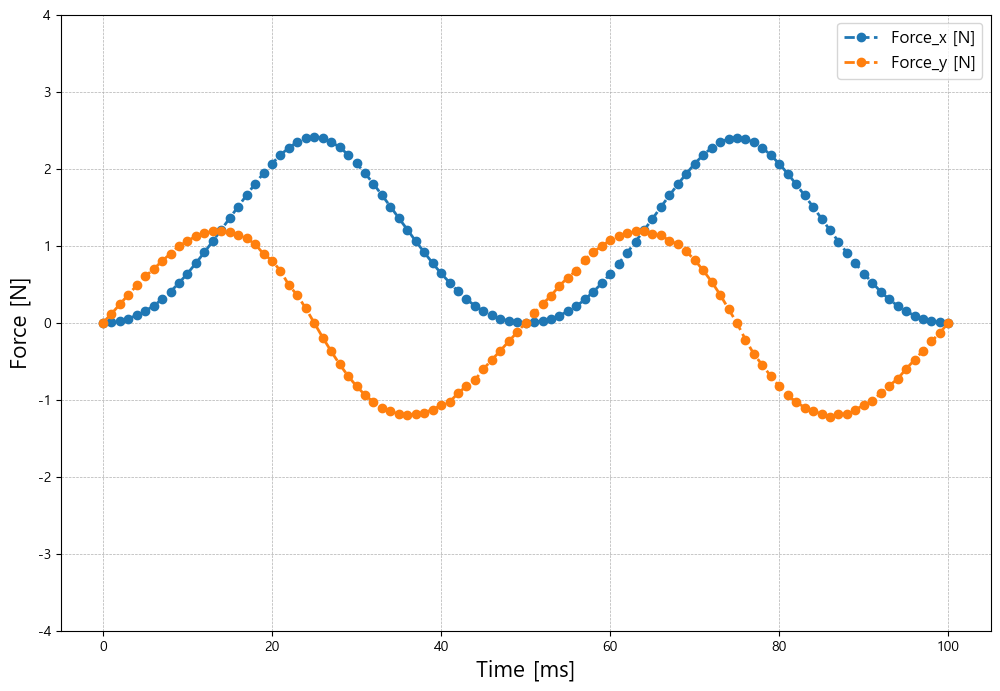

In [22]:
## 데이터 처리 ##

csv_name = "data_a_current_moving.csv"
pd_data = pd.read_csv(csv_name)

# pd_data의 헤더 변경
pd_data.columns = ["Time [ms]", "Force_x [N]", "Force_y [N]"]

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 그래프 그리기
plt.figure(figsize=(12, 8))

# Time [ms]를 x축으로, Force_x [N], Force_y [N], Force_z [N]를 y축으로 설정
plt.plot(pd_data["Time [ms]"], pd_data["Force_x [N]"], marker='o', linestyle='--', linewidth=2, markersize=6, label="Force_x [N]")
plt.plot(pd_data["Time [ms]"], pd_data["Force_y [N]"], marker='o', linestyle='--', linewidth=2, markersize=6, label="Force_y [N]")

# 그래프 제목 및 축 레이블 설정
plt.xlabel("Time [ms]", fontsize=16)
plt.ylabel("Force [N]", fontsize=16)

# y축 범위 설정
plt.ylim(-4, 4)  # 예시: y축 범위를 -10에서 10으로 설정

# 범례 추가
plt.legend(fontsize=12)

# 그리드 추가
plt.grid(True, linestyle='--', linewidth=0.5)

# 그래프 표시
plt.show()

In [18]:
table_name = "current_table"

oModule = oDesign.GetModule("ReportSetup")
oModule.CreateReport(f"{table_name}", "Transient", "Rectangular Plot", "Setup1 : Transient", 
	[
		"Domain:="		, "Sweep"
	], 
	[
		"Time:="		, ["All"],
		"depth:="		, ["Nominal"],
		"num_pole:="		, ["Nominal"],
		"m_w:="			, ["Nominal"],
		"m_h:="			, ["Nominal"],
		"gap_w:="		, ["Nominal"],
		"my_th:="		, ["Nominal"],
		"num_slot:="		, ["Nominal"],
		"airgap:="		, ["Nominal"],
		"t_w:="			, ["Nominal"],
		"t_g:="			, ["Nominal"],
		"J_rated:="		, ["Nominal"],
		"cy_th:="		, ["Nominal"],
		"c_w:="			, ["Nominal"],
		"c_h:="			, ["Nominal"],
		"t_h:="			, ["Nominal"],
		"my_w:="		, ["Nominal"],
		"turn_c:="		, ["Nominal"],
		"current_rated:="	, ["Nominal"],
		"gamma:="		, ["Nominal"],
		"theta_elec_offset:="	, ["Nominal"],
		"freq_elec:="		, ["Nominal"]
	], 
	[
		"X Component:="		, "Time",
		"Y Component:="		, ["InputCurrent(winding_a)","InputCurrent(winding_b)","InputCurrent(winding_c)"]
	])

csv_name = "a_current_moving.csv"
dir_csv = os.getcwd() + f"\\{csv_name}"

oModule.ExportToFile(f"{table_name}", dir_csv, False)

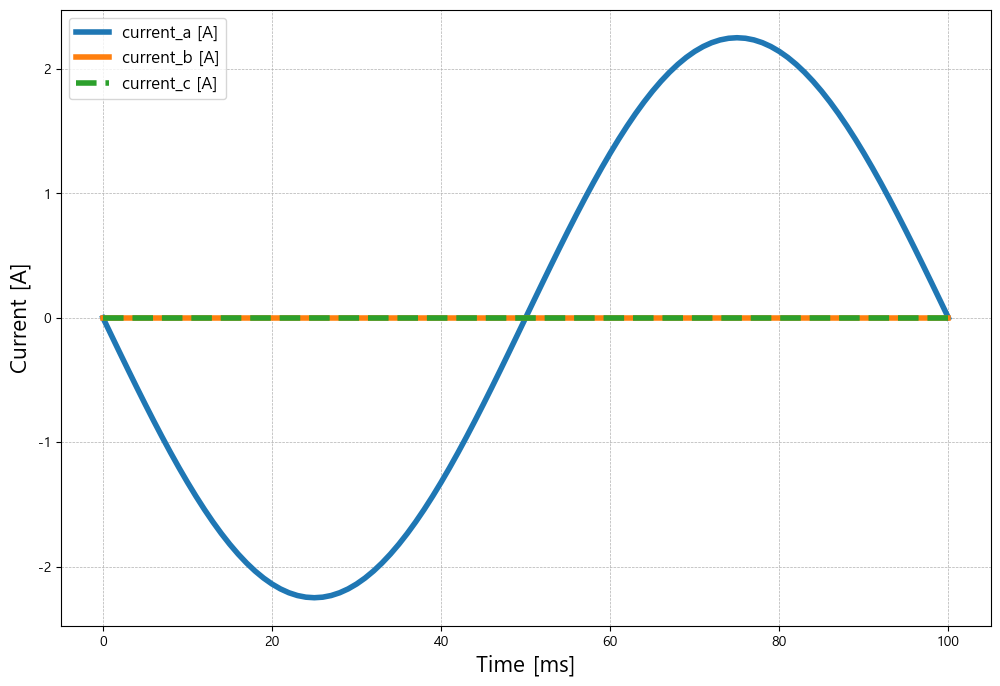

In [21]:
## 데이터 처리 ##

csv_name = "a_current_moving.csv"
pd_data = pd.read_csv(csv_name)

# pd_data의 헤더 변경
pd_data.columns = ["Time [ms]", "current_a [A]", "current_b [A]", "current_c [A]"]

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 그래프 그리기
plt.figure(figsize=(12, 8))

# Time [ms]를 x축으로, Force_x [N], Force_y [N], Force_z [N]를 y축으로 설정
plt.plot(pd_data["Time [ms]"], pd_data["current_a [A]"], linestyle='-', linewidth=4, markersize=6, label="current_a [A]")
plt.plot(pd_data["Time [ms]"], pd_data["current_b [A]"], linestyle='-', linewidth=4, markersize=6, label="current_b [A]")
plt.plot(pd_data["Time [ms]"], pd_data["current_c [A]"], linestyle='--', linewidth=4, markersize=6, label="current_c [A]")

# 그래프 제목 및 축 레이블 설정
plt.xlabel("Time [ms]", fontsize=16)
plt.ylabel("Current [A]", fontsize=16)

# 범례 추가
plt.legend(fontsize=12)

# 그리드 추가
plt.grid(True, linestyle='--', linewidth=0.5)

# 그래프 표시
plt.show()

In [20]:
## project 저장 ##

# M2D.save_project()